----
# **<span style="color:darkmagenta">PROYECTO EDA - BANK MARKETING</span>**
----

---
---
## <span style="color:gray">**1. Importación de librerías**</span> 📂

In [ ]:
# Tratamiento de datos
import numpy as np
import pandas as pd 

# Visualización de datos
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Configuración de ruta
import sys
sys.path.append('../')

# Importación de funciones personalizadas
from src.soporte import columnas_df
from src.soporte import boxplots
from src.soporte import graficos_categoricos
from src.soporte import number_vs_target
from src.soporte import category_vs_target


---
---
## <span style="color:gray">**2. Carga de datos**</span> 📥

In [2]:
# Utilizamos los datos que hemos guardado tras la limpieza
bank_data_limpio = pd.read_csv("../data/output/bank_data_limpio.csv")
customer_data_limpio = pd.read_csv("../data/output/customer_data_limpio.csv")

In [3]:
# Configuración para mostrar todas las columnas
pd.set_option('display.max_columns', None) 

----
# <span style="color:darkmagenta">**Desarrollo del proyecto - 3**</span> 
----


---
---
## <span style="color:gray">**Integración de datasets**</span> 🔗

In [4]:
df_integrado = pd.merge(bank_data_limpio, customer_data_limpio, on='id', how='left')

# Lo guardamos en un csv
df_integrado.to_csv("../data/output/df_integrado.csv", index=False)

Recordamos la estructura del dataset:

In [5]:
df_integrado.head(3)

,age,job,marital_status,education_level,default,housing_loan,personal_loan,contact_method,campaign_contacts,previous_contacts,previous_campaign_outcome,employment_variation_rate,consumer_price_index,consumer_confidence_index,euribor_3m_rate,number_employees,subscribed,id,contacted_before,year,month,income,num_kids_home,num_teens_home,customer_since,num_web_visits_month
0,38,housemaid,married,basic_4y,no,no,no,telephone,1,0,nonexistent,1.1,93.994,-36.4,4.857000,5191,no,089b39d8-e4d0-461b-87d4-814d71e0e079,no,2019,August,161770,1,0,2012-04-04,29
1,57,services,married,high_school,no,no,no,telephone,1,0,nonexistent,1.1,93.994,-36.4,3.616521,5191,no,e9d37224-cb6f-4942-98d7-46672963d097,no,2016,September,85477,1,1,2012-12-30,7
2,37,services,married,high_school,no,si,no,telephone,1,0,nonexistent,1.1,93.994,-36.4,4.857000,5191,no,3f9f49b5-e410-4948-bf6e-f9244f04918b,no,2019,February,147233,1,1,2012-02-02,5


La columna `id` la podemos eliminar ya que solo la necesitábamos para la integración de los dataset

In [6]:
df_integrado = df_integrado.drop('id', axis=1)

In [7]:
columnas_df(df_integrado)

Las columnas del DataFrame que estamos analizando son:


Index(['age', 'job', 'marital_status', 'education_level', 'default',
       'housing_loan', 'personal_loan', 'contact_method', 'campaign_contacts',
       'previous_contacts', 'previous_campaign_outcome',
       'employment_variation_rate', 'consumer_price_index',
       'consumer_confidence_index', 'euribor_3m_rate', 'number_employees',
       'subscribed', 'contacted_before', 'year', 'month', 'income',
       'num_kids_home', 'num_teens_home', 'customer_since',
       'num_web_visits_month'],
      dtype='str')

Información básica de las columnas:

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        43000 non-null  int64  
 1   job                        43000 non-null  str    
 2   marital_status             43000 non-null  str    
 3   education_level            43000 non-null  str    
 4   default                    43000 non-null  str    
 5   housing_loan               43000 non-null  str    
 6   personal_loan              43000 non-null  str    
 7   contact_method             43000 non-null  str    
 8   campaign_contacts          43000 non-null  int64  
 9   previous_contacts          43000 non-null  int64  
 10  previous_campaign_outcome  43000 non-null  str    
 11  employment_variation_rate  43000 non-null  float64
 12  consumer_price_index       43000 non-null  float64
 13  consumer_confidence_

,count,mean,std,min,25%,50%,75%,max
age,43000.0,39.74,9.82,17.00,33.00,38.00,46.00,98.00
campaign_contacts,43000.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00
previous_contacts,43000.0,0.17,0.50,0.00,0.00,0.00,0.00,7.00
employment_variation_rate,43000.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
consumer_price_index,43000.0,93.57,0.58,92.20,93.08,93.57,93.99,94.77
consumer_confidence_index,43000.0,-40.51,4.64,-50.80,-42.70,-41.80,-36.40,-26.90
euribor_3m_rate,43000.0,3.62,1.54,0.63,1.47,4.08,4.96,5.04
number_employees,43000.0,5166.84,72.34,4964.00,5099.00,5191.00,5228.00,5228.00
year,43000.0,2017.01,1.42,2015.00,2016.00,2017.00,2018.00,2019.00
income,43000.0,93241.20,50498.32,5841.00,49610.00,93050.50,136744.50,180802.00



Estadísticos de las variables categóricas:



,count,unique,top,freq
job,43000,12,administrative,10873
marital_status,43000,4,married,25999
education_level,43000,8,university_degree,12722
default,43000,2,no,42997
housing_loan,43000,2,si,22498
personal_loan,43000,2,no,36468
contact_method,43000,2,cellular,27396
previous_campaign_outcome,43000,3,nonexistent,37103
subscribed,43000,2,no,38156
contacted_before,43000,2,no,41412


In [8]:
cols_fecha = ['customer_since']
for col in cols_fecha:
    df_integrado[col] = pd.to_datetime(df_integrado[col])

---
---
## <span style="color:gray">**EDA sobre el dataset final**</span> 🧩

---

### <span style="color:darkgray">**1. Análisis univariado**</span>  

### <span style="color:darkgray">Distribución de las columnas numéricas</span>

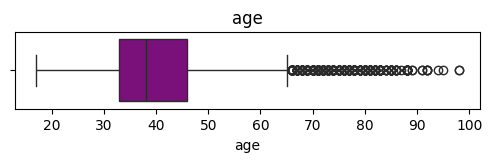

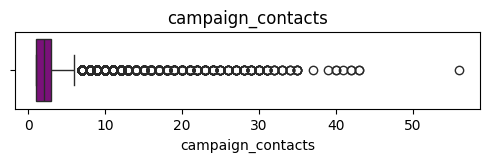

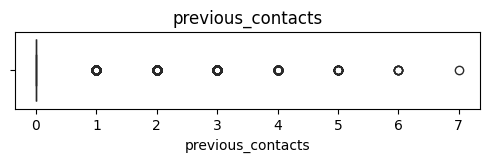

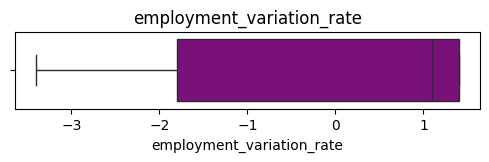

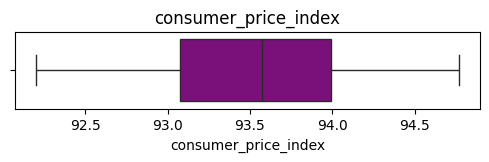

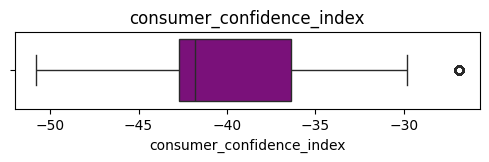

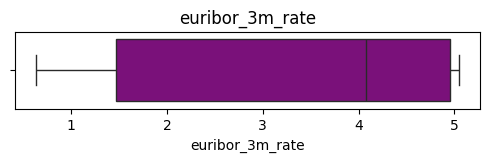

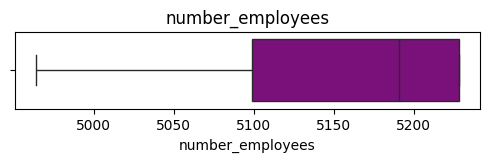

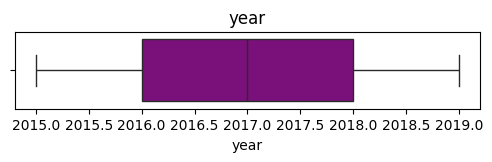

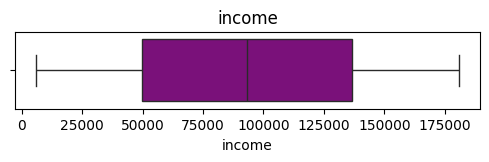

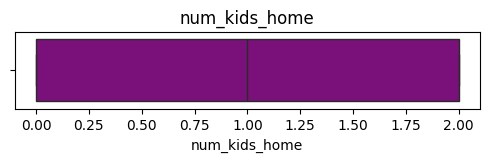

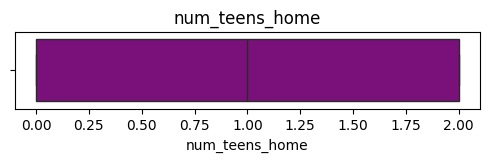

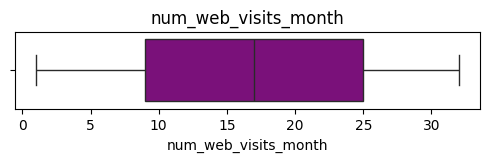

In [9]:
# Llamamos a la función guardada en el documento soporte.py
boxplots(df_integrado)

| Variable | Rango / Valores | Mediana | Observaciones |
|----------|----------------|---------|---------------|
| `age` | 18 – 100 | ~40 | La mayoría entre 30–50; varios outliers altos (70–100). |
| `campaign_contacts` | 1 – ~50 | 1–5 | Concentrado en valores bajos; algunos clientes reciben muchos contactos. |
| `previous_contacts` | 0 – 7 | 0 | Mayoría sin contactos previos; pocos casos dispersos. |
| `employment_variation_rate` | -3 a +1.5 | >0 | Distribución amplia, indica variación económica. |
| `consumer_price_index` | 92.5 – 94.8 | 93.7 | Poca variabilidad; indicador económico estable. |
| `consumer_confidence_index` | -50 a -30 | -40 | Algunos outliers; refleja cambios puntuales en confianza del consumidor. |
| `euribor_3m_rate` | 1 – 5 | ~4 | Amplia variación en tasas de interés. |
| `number_employees` | 5000 – 5220 | ~5150 | Muy poca variabilidad; empresa estable en tamaño. |
| `year` | 2016-2018 | 2017 | ------. |
| `income` | 0 – 175000 | 80k–90k | Rango amplio; algunos clientes con ingresos muy altos. |
| `num_kids_home` | 0 – 2 | 1 | Distribución bastante uniforme; pocos casos extremos. |
| `num_teens_home` | 0 – 2 | 1 | Similar a `num_kids_home`; sin outliers. |
| `num_web_visits_month` | 1 – 32 | 15–18 | Distribución equilibrada. |

**Resumen general**

- Variables económicas (índices, tasas) → más estables o controladas

- Variables de comportamiento (contactos, visitas) → más dispersas y con outliers

- Variables demográficas (edad, hijos, ingresos) → muestran diversidad clara en clientes

A partir del análisis anterior, se ha identificado que las siguientes variables presentan una baja relevancia explicativa debido a su escasa variabilidad o limitada capacidad informativa:

`previous_contacts` 

- Esta variable muestra una alta concentración de valores en 0, por lo que esta variable apenas aporta información relevante.

`num_kids_home` / `num_teens_home`

- Estas variables tienen muy poca variación entre los registros, lo que dificulta que ayuden a diferenciar unos casos de otros.

`number_employees`

- Se observa que esta variable es prácticamente constante, por lo que no aporta información significativa para el análisis.


En consecuencia, eliminamos estas variables del conjunto de datos para simplificar el modelo y evitar que introduzcan ruido innecesario:

- Antes de eliminarlas, creamos una copia del DataFrame:

In [10]:
df_final = df_integrado.copy()

- Eliminamos las varibles mencionadas anteriormente:

In [11]:
cols_eliminar = ['previous_contacts', 'num_kids_home', 'num_teens_home', 'number_employees']

df_final = df_final.drop(columns=cols_eliminar)

- Guardamos el DataFrame:

In [12]:
df_final.to_csv("../data/output/df_final.csv", index=False)

---
### <span style="color:darkgray">Distribución de las columnas categóricas</span>

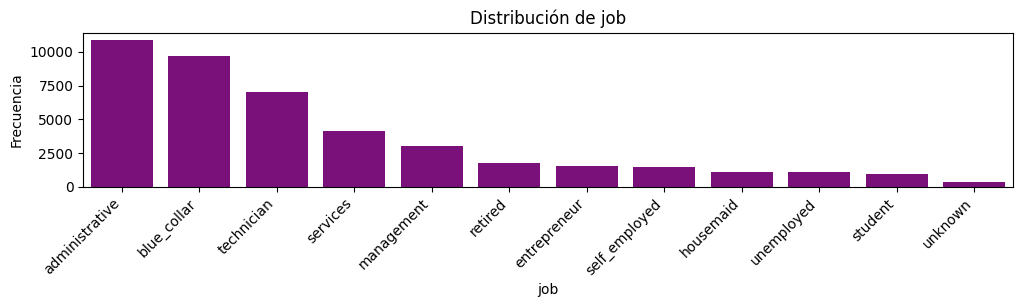

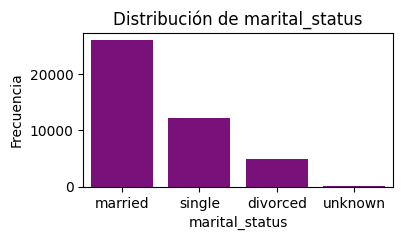

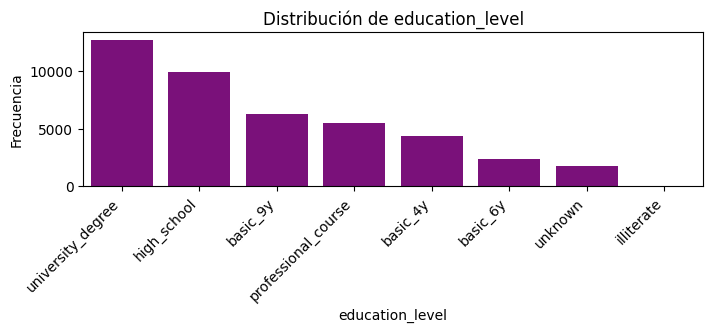

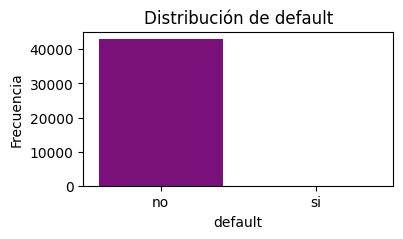

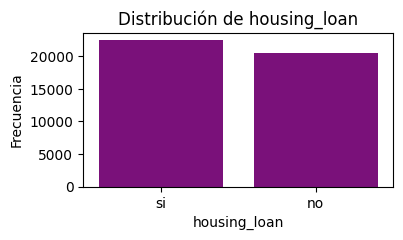

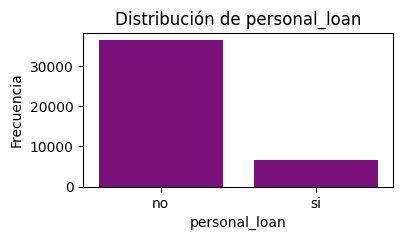

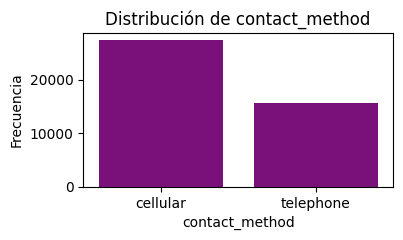

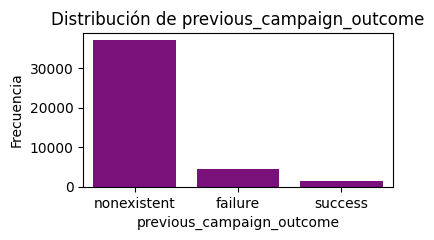

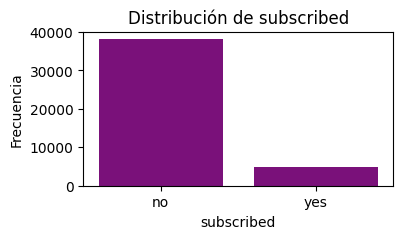

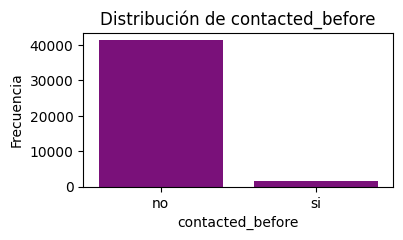

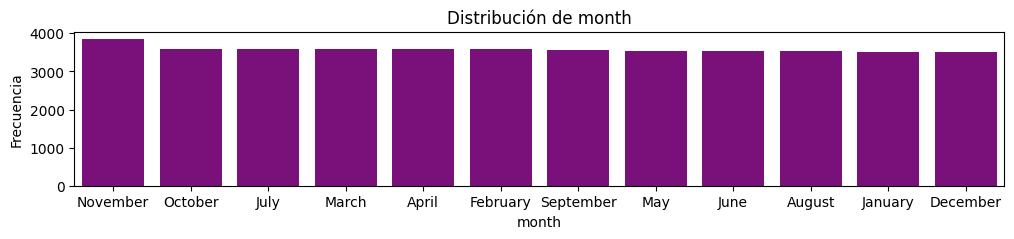

In [13]:
graficos_categoricos(df_integrado, rotar_columnas=['job', 'education_level'])

| Variable                     | Predomina                                      | Observaciones                                                                 |
|-----------------------------|-----------------------------------------------|------------------------------------------------------------------------------|
| `job`                       | *administrative, blue-collar, technician*       | La mayoría pertenece a trabajos técnicos o administrativos.                 |
| `marital_status`            | *married, single*                                       | La mayoría de los clientes están casados.                                                         |
| `education_level`           | *university degree, high school*                | Predominan niveles educativos medios y superiores.                          |
| `default`                   | *no*                                            | Muy pocos clientes han incumplido pagos.                                    |
| `housing_loan`              | Ligeramente *yes*                               | Distribución bastante equilibrada.                                          |
| `personal_loan`             | *no*                                            | La mayoría no tiene préstamo personal.                                      |
| `contact_method`            | *mobile*                                        | Se usa más el móvil que el teléfono fijo.                                   |
| `previous_campaign_outcome` | *nonexistent*                                   | Muy pocos casos de success; muchos no fueron contactados antes.             |
| `subscribed`                | *no*                                            | Dataset desbalanceado (clase *no* mucho mayor que *yes*).                       |
| `contacted_before`          | *no*                                            | Confirma que la mayoría de los clientes no había sido contactada previamente.            |
| `month`                     | Ligeramente *November*                          | Distribución bastante equilibrada.            |

---
### <span style="color:darkgray">**2. Análisis bivariado**</span>  

### <span style="color:darkgray">Relación entre columnas numéricas y suscripción</span>  

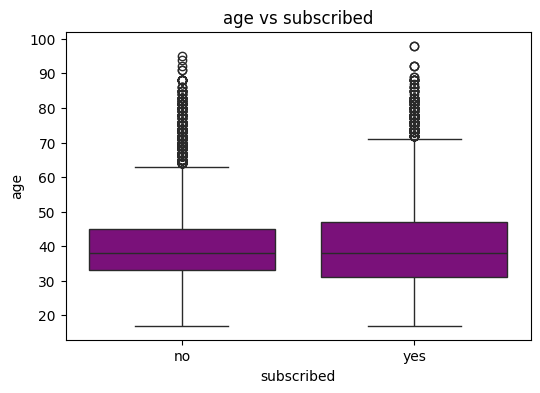

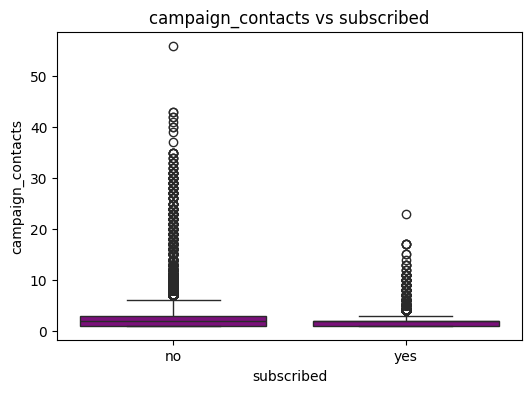

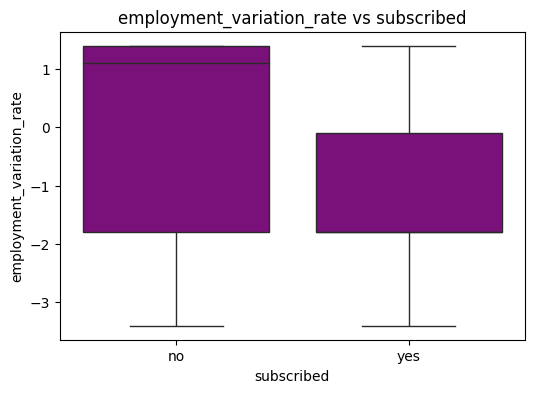

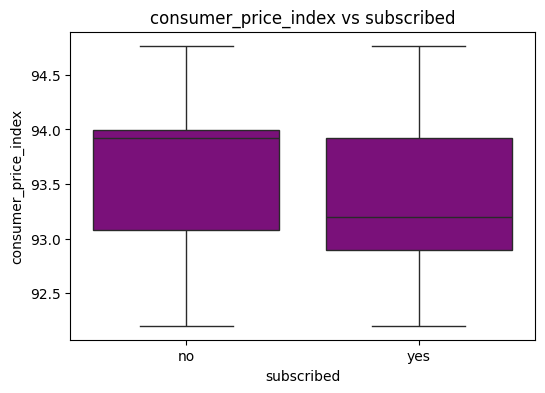

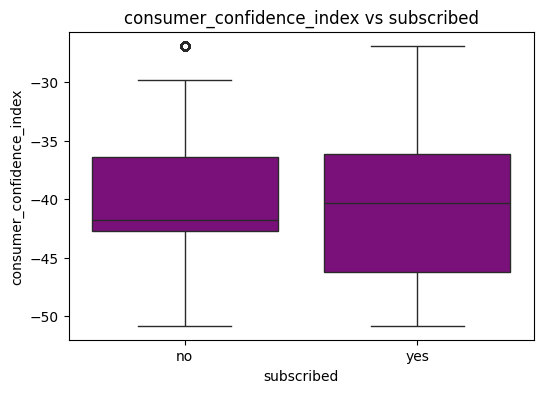

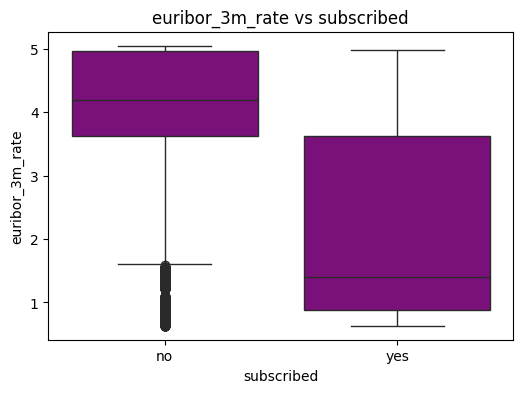

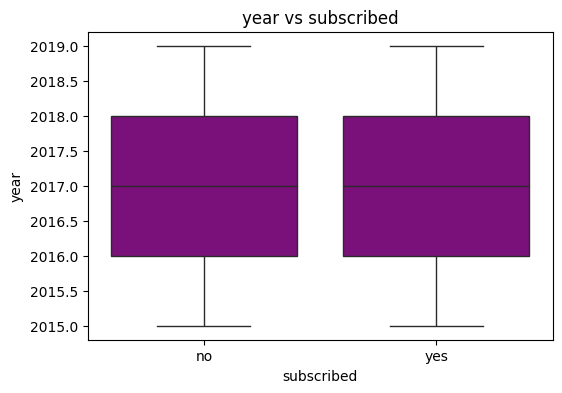

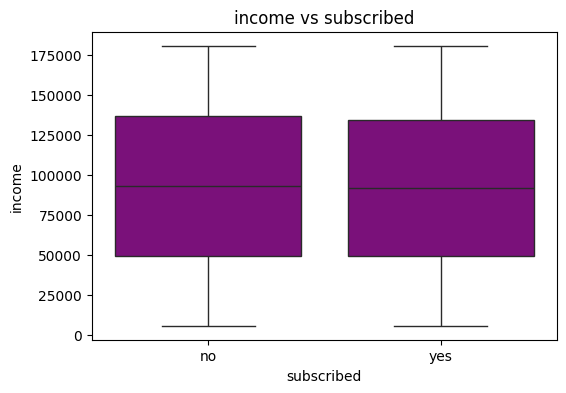

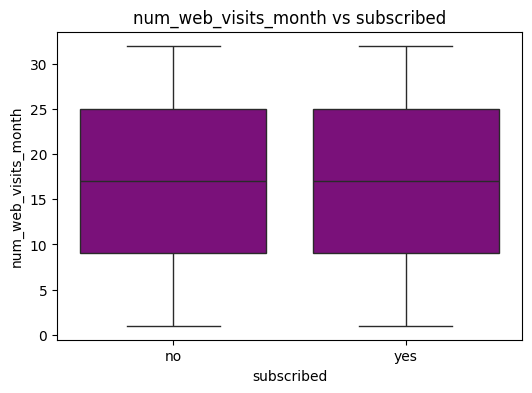

In [14]:
number_vs_target(df_final, "subscribed")

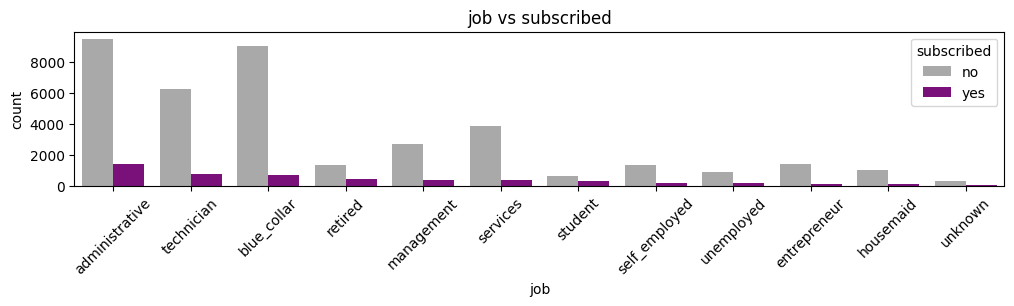

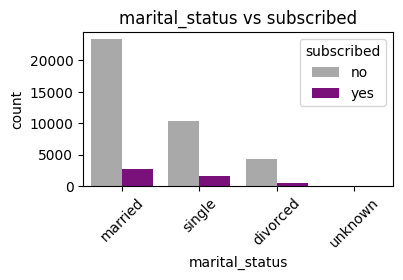

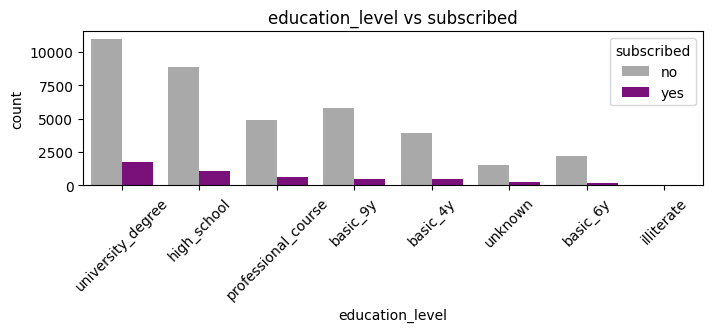

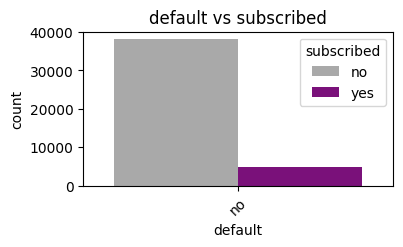

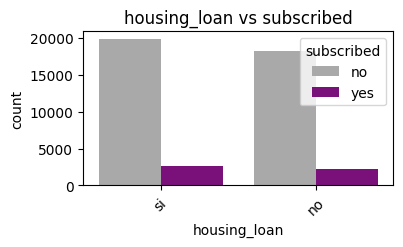

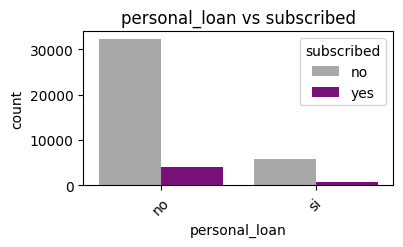

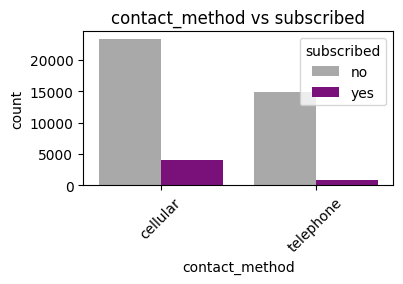

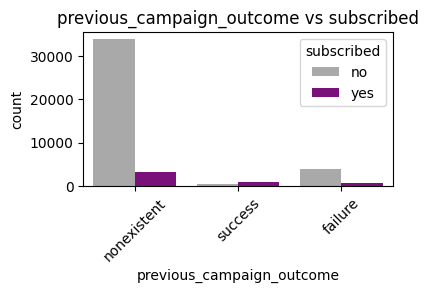

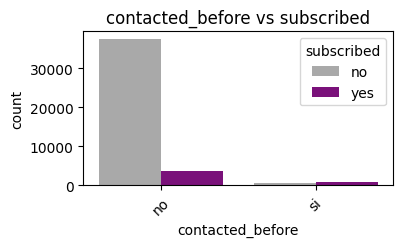

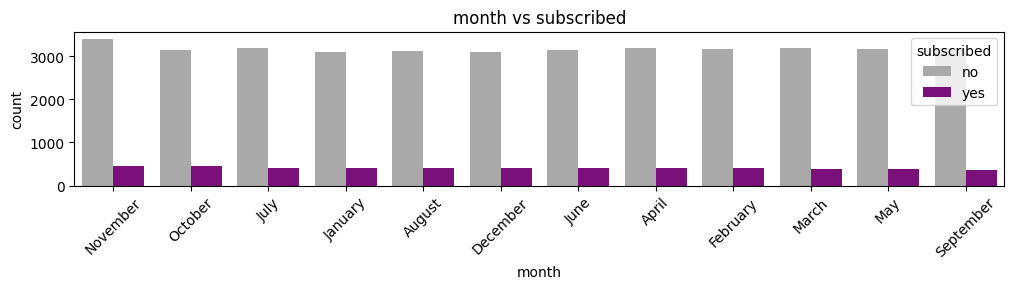

In [15]:
category_vs_target(df_final, "subscribed")

### <span style="color:darkgray">**4. Análisis multivariado**</span>  

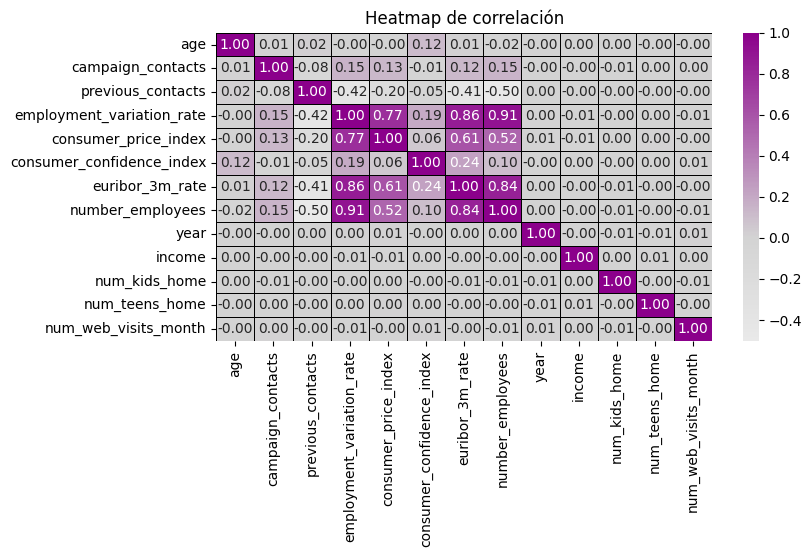

In [16]:
# Seleccionar solo columnas numéricas
col_num = df_integrado.select_dtypes(include='number')

# Matriz de correlación
corr = col_num.corr()

# Mapa de colores personalizado
colors = ["white", "lightgrey", "darkmagenta"]  # baja → alta correlación
cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

# Dibujar el heatmap
plt.figure(figsize=(8, 4)) 
sns.heatmap(
    corr, 
    annot=True, 
    fmt=".2f", 
    cmap=cmap, 
    center=0, 
    linewidths=0.5, 
    linecolor='black'
    )
plt.title("Heatmap de correlación")
plt.show()

---
---
## <span style="color:gray">**Insights**</span> 💡

---
---
## <span style="color:gray">**Conclusiones finales**</span> 📝